# 🤖 手勢石頭-剪刀-布（0, 2, 5）模型訓練與匯出 TFLite
本筆記展示如何使用 Sign Language Digits Dataset 中的部分資料（只保留 0、2、5）訓練一個輕量級分類模型，以辨識簡單手勢：石頭、剪刀、布，並將訓練完成的模型轉換為 TensorFlow Lite 格式，方便在手機端部署（以Chaquopy為例）。

In [1]:
from google.colab import files
files.upload()  # 上傳 kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [7]:
import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content"
!ls /content

kaggle.json  Sign-language-digits-dataset      X.npy
sample_data  sign-language-digits-dataset.zip  Y.npy


## ⚙️ 步驟 1：安裝 Kaggle 並下載資料集

In [2]:
# 安裝 Kaggle CLI 工具
!pip install kaggle --quiet

# 從 Kaggle 下載 Sign Language Digits 資料集（共 0-9 十個手勢圖片）
!kaggle datasets download -d ardamavi/sign-language-digits-dataset

# 解壓縮下載的 ZIP 檔案
!unzip -q sign-language-digits-dataset.zip


Dataset URL: https://www.kaggle.com/datasets/ardamavi/sign-language-digits-dataset
License(s): CC-BY-SA-4.0
  0% 0.00/16.8M [00:00<?, ?B/s]
100% 16.8M/16.8M [00:00<00:00, 585MB/s]


## 📁 步驟 2：過濾並載入影像（僅保留 0, 2, 5）

讀取jpg版本

讀取.npy版本

In [3]:
import numpy as np, tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 載入資料
X_all = np.load("X.npy")  # shape: (2062, 64, 64)
Y_all = np.load("Y.npy")  # shape: (2062, 10)

# 從 one-hot 還原標籤
labels = np.argmax(Y_all, axis=1)

# 選出 0, 2, 5 對應石頭、剪刀、布
KEEP = [0, 2, 5]
LABEL_MAP = {0: 0, 2: 1, 5: 2}
selected = np.isin(labels, KEEP)
X_sel = X_all[selected]
y_sel = labels[selected]

# 灰階擴通道 → resize → normalize → RGB
X_sel = np.expand_dims(X_sel, -1).astype("float32")
X_resized = tf.image.resize(X_sel, [96, 96])
X_resized = X_resized / 255.0
X_input = tf.image.grayscale_to_rgb(X_resized)

# 處理標籤
y_mapped = np.array([LABEL_MAP[v] for v in y_sel])
y_onehot = to_categorical(y_mapped, num_classes=3)

# 分割訓練/驗證
X_train, X_test, y_train, y_test = train_test_split(
    X_input.numpy(), y_onehot, test_size=0.1, stratify=y_mapped
)


## 🧠 步驟 3：建立 MobileNetV2 模型（3 分類）

In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 資料增強
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# MobileNetV2 基底
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = True

# 加入分類器
model = models.Sequential([
    layers.Input(shape=(96, 96, 3)),
    data_aug,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# 開始訓練
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.3966 - loss: 1.3296 - val_accuracy: 0.3387 - val_loss: 1.1540
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 963ms/step - accuracy: 0.6328 - loss: 0.7860 - val_accuracy: 0.3387 - val_loss: 1.1422
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7613 - loss: 0.5947 - val_accuracy: 0.3387 - val_loss: 1.1224
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 957ms/step - accuracy: 0.7393 - loss: 0.5847 - val_accuracy: 0.3387 - val_loss: 1.1435
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8545 - loss: 0.4197 - val_accuracy: 0.3387 - val_loss: 1.2048
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8500 - loss: 0.3268 - val_accuracy: 0.3387 - val_loss: 1.2052


## 💾 步驟 4：轉換模型為 TensorFlow Lite

In [58]:
# 將訓練好的模型轉換為 TFLite 格式
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("rps_mobilenetv2.tflite", "wb") as f:
    f.write(tflite_model)
print("✅ 已成功匯出為 rps_mobilenetv2.tflite")

Saved artifact at '/tmp/tmptbfduf2j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_1272')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138711987680464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711987681424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711962944144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711987677584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711987682768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711962945296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711962945680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711962946064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711962945872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138711962944528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13871196294

## 🖼️ 預測測試集並顯示影像（強化對比）

In [48]:
import time, numpy as np

# X_test 目前形狀 (N, 96, 96, 3)，model 已在前面訓練完成
N  = X_test.shape[0]

start = time.perf_counter()
_ = model.predict(X_test, batch_size=32, verbose=0)   # 推論
elapsed = time.perf_counter() - start

print(f"Total time on {N} images  : {elapsed:.3f} s")
print(f"Avg per image            : {elapsed/N*1000:.2f} ms")


Total time on 62 images  : 1.431 s
Avg per image            : 23.09 ms


1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step
Pixel range of image 0: min=0.0008953825454227626, max=0.0037882865872234106


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


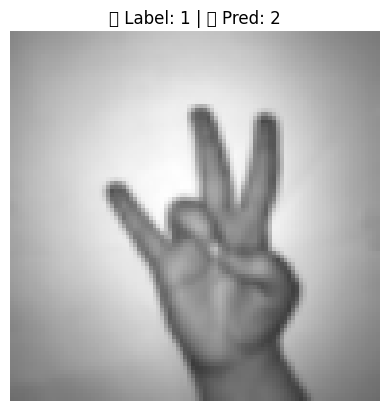

Pixel range of image 1: min=0.0007740604924038053, max=0.003765218425542116


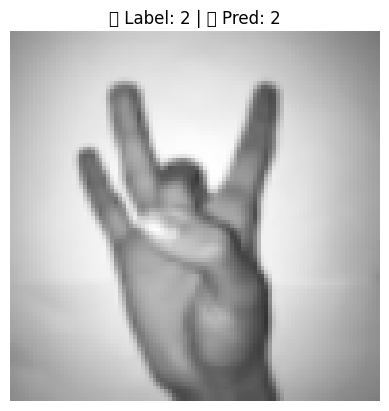

Pixel range of image 2: min=0.0009701387607492507, max=0.003721218556165695


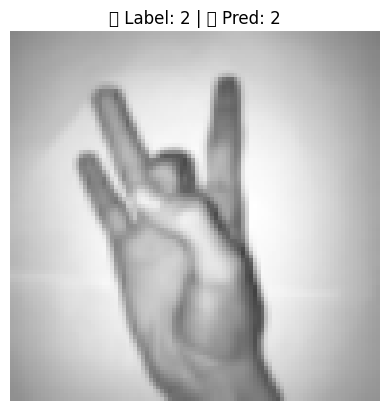

Pixel range of image 3: min=0.0009474978432990611, max=0.003734033787623048


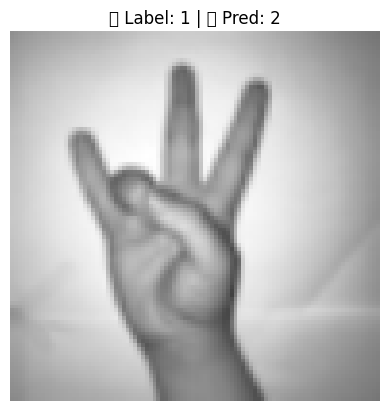

Pixel range of image 4: min=0.00041607889579609036, max=0.0037643644027411938


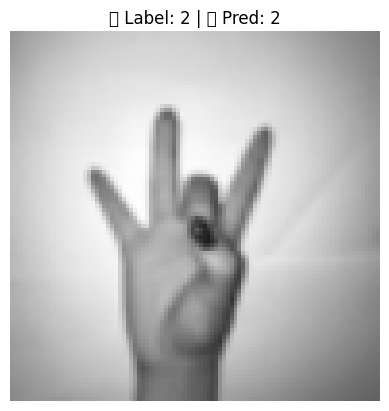

Pixel range of image 5: min=0.0005779814091511071, max=0.00370498513802886


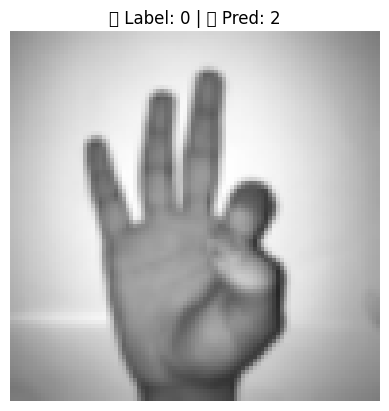

Pixel range of image 6: min=0.0005933599313721061, max=0.0037639369256794453


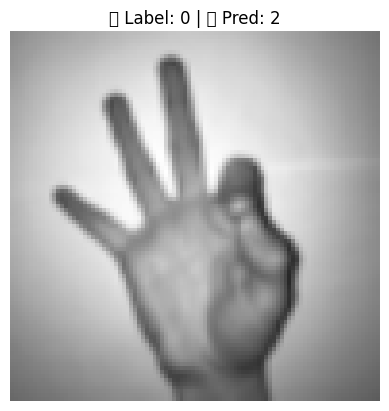

Pixel range of image 7: min=0.00048699064063839614, max=0.003758810693398118


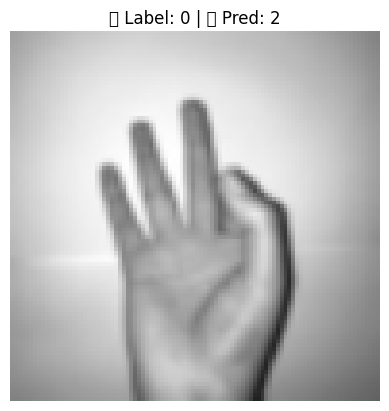

Pixel range of image 8: min=0.00045751669676974416, max=0.003744713496416807


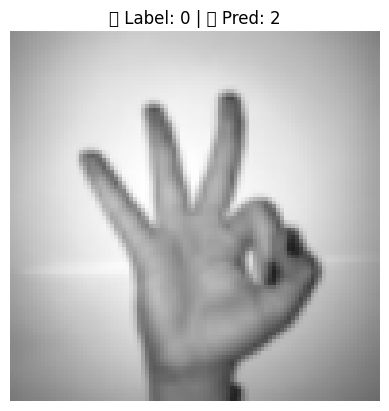

Pixel range of image 9: min=0.0003998462052550167, max=0.0037459952291101217


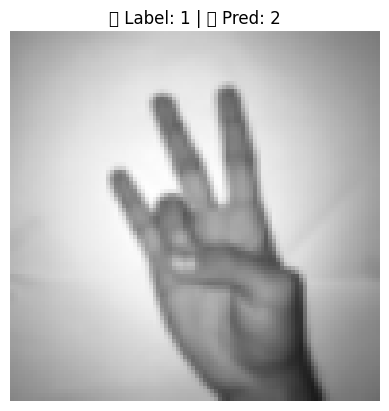

In [39]:
for i in range(10):
    img = X_test[i]
    normed = img / img.max()  # 強化對比再顯示
    print(f"Pixel range of image {i}: min={img.min()}, max={img.max()}")
    plt.imshow(normed)
    plt.title(f"✅ Label: {np.argmax(y_test[i])} | 🔮 Pred: {np.argmax(preds[i])}")
    plt.axis('off')
    plt.show()


## 🖼️ 使用傳統ML進行分析比較

In [40]:
# ========= 0. 依賴 =========
import numpy as np
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import joblib   # 儲存模型用

# ========= 1. 載入資料 =========
X_all = np.load("X.npy")          # (2062, 64, 64) 灰階影像
Y_all = np.load("Y.npy")          # (2062, 10)  one-hot 標籤
labels = np.argmax(Y_all, axis=1) # 轉成 0-9 整數

# --------- 1-a 取三類 0/2/5 ---------
KEEP = [0, 2, 5]                  # 石頭(0) 剪刀(2) 布(5)
LABEL_MAP = {0:0, 2:1, 5:2}       # 重新編碼→0,1,2
keep_idx = np.isin(labels, KEEP)
X_sel    = X_all[keep_idx]
y_sel    = np.array([LABEL_MAP[v] for v in labels[keep_idx]])

print(f"樣本數：{X_sel.shape[0]}  張")  # 約 619 張

# ========= 2. HoG 特徵提取 =========
def img2hog(img):
    return hog(img,
               orientations=9,
               pixels_per_cell=(8, 8),
               cells_per_block=(2, 2),
               block_norm="L2-Hys")

features = np.array([img2hog(im) for im in X_sel], dtype=np.float32)
print("HoG 向量維度 =", features.shape[1])

# ========= 3. 切分資料 =========
X_tr, X_te, y_tr, y_te = train_test_split(
    features, y_sel, test_size=0.1, stratify=y_sel, random_state=42)

# ========= 4. 訓練 SVM =========
clf = LinearSVC(C=1.0, max_iter=5000)
clf.fit(X_tr, y_tr)

# ========= 5. 評估 =========
y_pred = clf.predict(X_te)
print("Accuracy :", accuracy_score(y_te, y_pred))
print(classification_report(y_te, y_pred, target_names=["石頭(0)","剪刀(2)","布(5)"]))

# ========= 6. 儲存模型 =========
joblib.dump(clf, "hog_svm_rps.pkl")
print("✅ 模型已存為 hog_svm_rps.pkl")


樣本數：618  張
HoG 向量維度 = 1764
Accuracy : 0.8548387096774194
              precision    recall  f1-score   support

       石頭(0)       0.78      0.90      0.84        20
       剪刀(2)       0.91      0.95      0.93        21
        布(5)       0.88      0.71      0.79        21

    accuracy                           0.85        62
   macro avg       0.86      0.86      0.85        62
weighted avg       0.86      0.85      0.85        62

✅ 模型已存為 hog_svm_rps.pkl


In [41]:
import numpy as np, joblib
from skimage.feature import hog

clf = joblib.load("hog_svm_rps.pkl")

def predict_rps(img64x64):
    feat = hog(img64x64,
               orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), block_norm="L2-Hys")
    pred = clf.predict([feat])[0]     # 0=石頭 1=剪刀 2=布
    return pred

# 測試
print("Predict =", predict_rps(X_sel[0]))


Predict = 0
